# Training vs Test Error

**Author:** Tohidul Islam Tareq

Simulation of how training size affects training and test error.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.figsize'] = (7, 4)


In [2]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X, y = load_diabetes(return_X_y=True)
rows = []
for train_size in np.arange(0.1, 1.0, 0.1):
    for seed in range(30):
        X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, random_state=seed)
        model = LinearRegression().fit(X_train, y_train)
        rows.append({
            'train_size': train_size,
            'train_mse': mean_squared_error(y_train, model.predict(X_train)),
            'test_mse': mean_squared_error(y_test, model.predict(X_test))
        })
errors = pd.DataFrame(rows).groupby('train_size', as_index=False).mean()
errors


,train_size,train_mse,test_mse
0,0.1,2400.125965,3865.586681
1,0.2,2647.408154,3344.516450
2,0.3,2727.317392,3195.118195
3,0.4,2725.123367,3150.144396
4,0.5,2756.889861,3106.739349
5,0.6,2802.143116,3075.536847
6,0.7,2830.885825,3031.478696
7,0.8,2834.401100,3041.916340
8,0.9,2842.089443,3105.413618


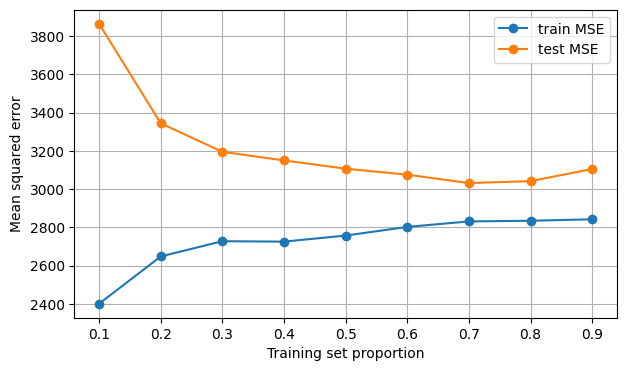

In [3]:
plt.figure()
plt.plot(errors['train_size'], errors['train_mse'], marker='o', label='train MSE')
plt.plot(errors['train_size'], errors['test_mse'], marker='o', label='test MSE')
plt.xlabel('Training set proportion'); plt.ylabel('Mean squared error')
plt.legend(); plt.grid(True); plt.show()
